# TS2 - Modelizando un ADC
Ana Fedeli

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# Funcion del TP anterior
def mi_funcion_sen(amplitud = 1, offset = 0, f0 = 1, fase = 0, N = 1000, fs = 1000):
    Ts = 1/fs
    tt = np.arange(start = 0, stop = N*Ts, step = Ts)
    xx = amplitud * np.sin(2 * np.pi * f0 * tt + fase) + offset
    return tt, xx

# Funcion de cuantizacion ADC
def mi_funcion_adc(xx, B, Vf):
    # paso de cuantizacion
    q = 2 * Vf / (2**B)

    # cuantizo: redondeo cada muestra al multiplo de q mas cercano
    xx_q = np.round(xx / q) * q

    # limito la salida al rango del ADC
    xx_q = np.clip(xx_q, -Vf, Vf)

    return xx_q, q


## Item a) - B = 4 bits, kn = 1

In [118]:
# Parametros del ADC
B  = 4       # bits
Vf = 1       # rango +/- Vf [V]
fs = 1000    # frecuencia de muestreo [Hz]
N  = 1000    # numero de muestras

# Parametros de la senoidal
# f0 = fs/N para que sea coherente con la ventana
f0 = fs / N
# Energia normalizada (varianza = 1) --> amplitud = Vf / sqrt(2)
amplitud = Vf / np.sqrt(2)
offset = 0
fase = 0

# Genero la senoidal
tt, s = mi_funcion_sen(amplitud, offset, f0, fase, N, fs)

# Calculo el ruido
xx_q, q = mi_funcion_adc(s, B, Vf)
Pq = q**2 / 12          # potencia de ruido de cuantizacion
kn = 1
Pn = kn * Pq            # potencia del ruido aditivo

# Genero el ruido gaussiano con potencia Pn
ruido = np.random.normal(0, np.sqrt(Pn), N)

# Señal ruidosa que entra al ADC
sR = s + ruido

# Cuantizo la señal ruidosa
sQ, q = mi_funcion_adc(sR, B, Vf)

print("q =", q, "V")
print("Pq =", Pq)
print("Pn =", Pn)


q = 0.125 V
Pq = 0.0013020833333333333
Pn = 0.0013020833333333333


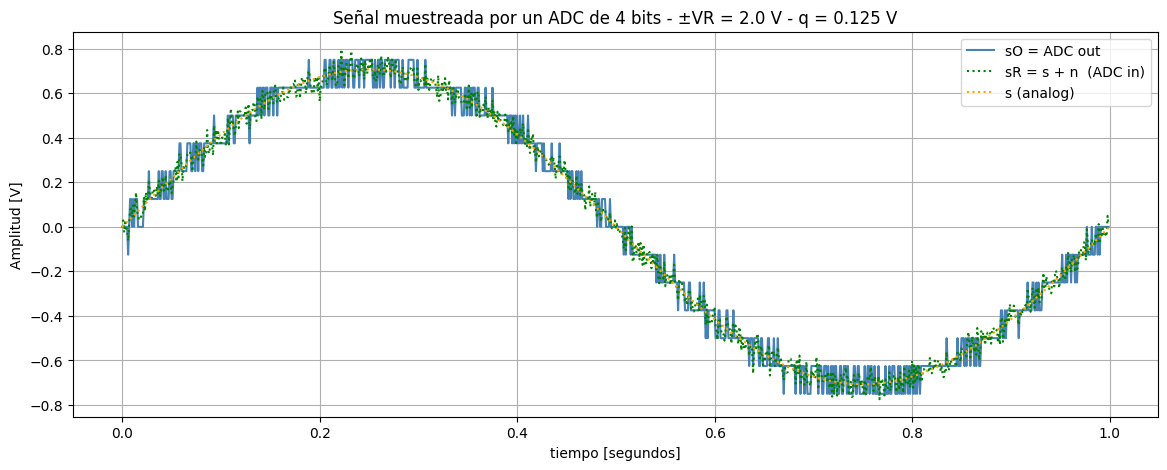

In [119]:
# Grafico 1: señal en el tiempo
plt.figure(figsize=(14, 5))
plt.plot(tt, sQ, color = 'steelblue', label = 'sO = ADC out')
plt.plot(tt, sR, ':', color = 'green',     label = 'sR = s + n  (ADC in)')
plt.plot(tt, s,  ':', color = 'orange',    label = 's (analog)')
plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits - ±VR = ' + str(Vf*2) + '.0 V - q = ' + str(q) + ' V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend()
plt.grid(True)
plt.show()


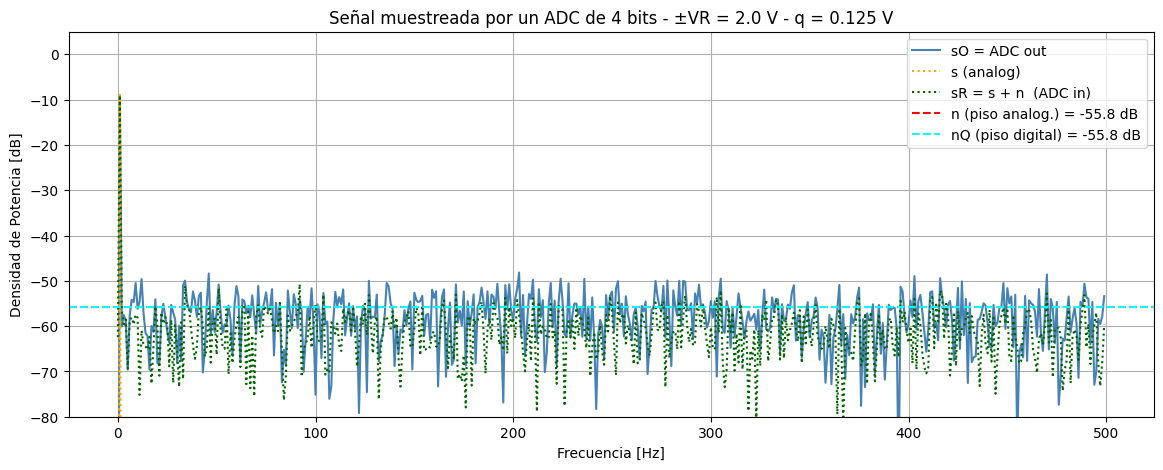

In [120]:
# Grafico 2: densidad de potencia en frecuencia
# Calculo la FFT de cada señal y paso a dB
def calcular_psd(xx, N):
    X = np.fft.fft(xx) / N
    psd = 10 * np.log10(np.abs(X[:N//2])**2 + 1e-20)
    return psd

freq = np.fft.fftfreq(N, d=1/fs)[:N//2]

psd_sQ = calcular_psd(sQ, N)
psd_s  = calcular_psd(s,  N)
psd_sR = calcular_psd(sR, N)

# Piso de ruido analitico
piso_n  = 10 * np.log10(Pn / (fs/2))
piso_nQ = 10 * np.log10(Pq / (fs/2))

plt.figure(figsize=(14, 5))
plt.plot(freq, psd_sQ, color = 'steelblue', label = 'sO = ADC out')
plt.plot(freq, psd_s,  ':',  color = 'orange',    label = 's (analog)')
plt.plot(freq, psd_sR, ':',  color = 'darkgreen',  label = 'sR = s + n  (ADC in)')
plt.axhline(piso_n,  color = 'red',  linestyle = '--', label = 'n (piso analog.) = ' + str(round(piso_n, 1)) + ' dB')
plt.axhline(piso_nQ, color = 'cyan', linestyle = '--', label = 'nQ (piso digital) = ' + str(round(piso_nQ, 1)) + ' dB')
plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits - ±VR = ' + str(Vf*2) + '.0 V - q = ' + str(q) + ' V')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend()
plt.grid(True)

plt.ylim(-80, 5)
plt.show()


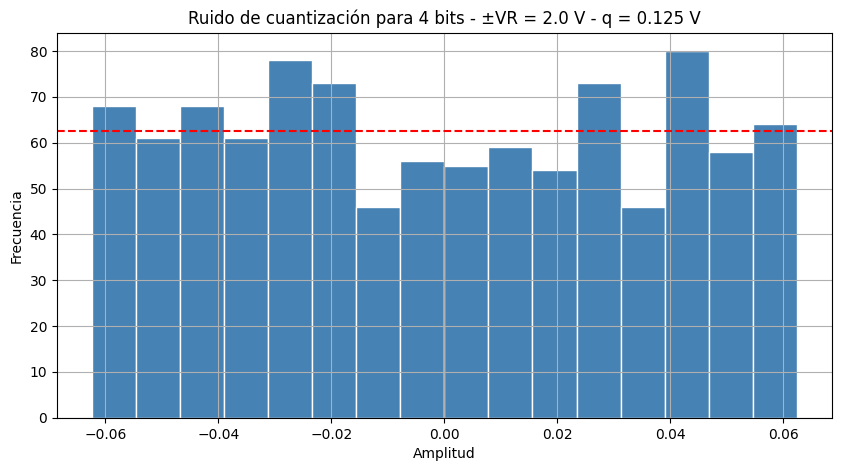

In [121]:
# Grafico 3: histograma del ruido de cuantizacion
ruido_cuantizacion = sQ - sR

plt.figure(figsize=(10, 5))
plt.hist(ruido_cuantizacion, bins = 16, color = 'steelblue', edgecolor = 'white')
plt.axhline(N / 16, color = 'red', linestyle = '--')   # linea uniforme esperada
plt.title('Ruido de cuantización para ' + str(B) + ' bits - ±VR = ' + str(Vf*2) + '.0 V - q = ' + str(q) + ' V')
plt.xlabel('Amplitud')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


## Item b) - B = 8 bits, kn = 1

In [122]:
# Item b) - B = 8 bits, kn = 1
B  = 8
Vf = 1
fs = 1000
N  = 1000
kn = 1

f0 = fs / N
amplitud = Vf / np.sqrt(2)
offset = 0
fase = 0

tt, s = mi_funcion_sen(amplitud, offset, f0, fase, N, fs)

xx_q, q = mi_funcion_adc(s, B, Vf)
Pq = q**2 / 12
Pn = kn * Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
sR = s + ruido
sQ, q = mi_funcion_adc(sR, B, Vf)

print("q =", q, "V")
print("Pq =", Pq)
print("Pn =", Pn)

q = 0.0078125 V
Pq = 5.086263020833333e-06
Pn = 5.086263020833333e-06


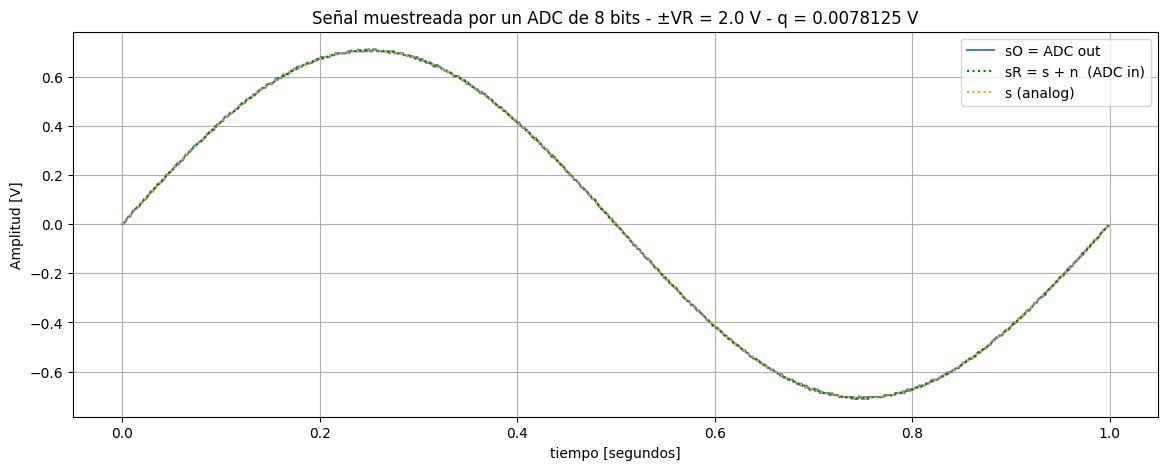

In [123]:
# Grafico 1: señal en el tiempo
plt.figure(figsize=(14, 5))
plt.plot(tt, sQ, color = 'steelblue', label = 'sO = ADC out')
plt.plot(tt, sR, ':', color = 'green',     label = 'sR = s + n  (ADC in)')
plt.plot(tt, s,  ':', color = 'orange',    label = 's (analog)')
plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits - ±VR = ' + str(Vf*2) + '.0 V - q = ' + str(q) + ' V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend()
plt.grid(True)
plt.show()


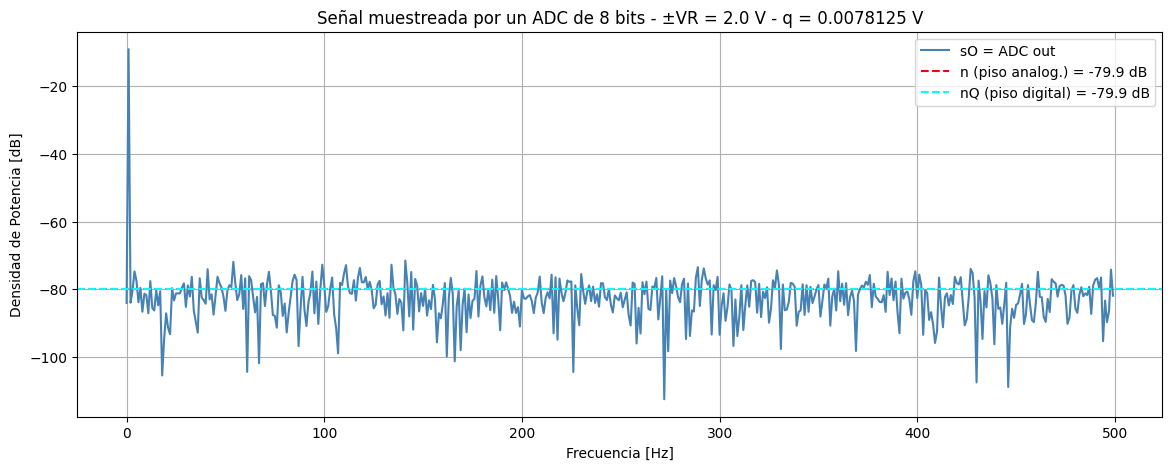

In [124]:
# Grafico 2: densidad de potencia en frecuencia
# Calculo la FFT de cada señal y paso a dB
def calcular_psd(xx, N):
    X = np.fft.fft(xx) / N
    psd = 10 * np.log10(np.abs(X[:N//2])**2 + 1e-20)
    return psd

freq = np.fft.fftfreq(N, d=1/fs)[:N//2]

psd_sQ = calcular_psd(sQ, N)
psd_s  = calcular_psd(s,  N)
psd_sR = calcular_psd(sR, N)

# Piso de ruido analitico
piso_n  = 10 * np.log10(Pn / (fs/2))
piso_nQ = 10 * np.log10(Pq / (fs/2))

plt.figure(figsize=(14, 5))
plt.plot(freq, psd_sQ, color = 'steelblue', label = 'sO = ADC out')
##plt.plot(freq, psd_s,  ':',  color = 'orange',    label = 's (analog)')
##plt.plot(freq, psd_sR, ':',  color = 'darkgreen',  label = 'sR = s + n  (ADC in)')
plt.axhline(piso_n,  color = 'red',  linestyle = '--', label = 'n (piso analog.) = ' + str(round(piso_n, 1)) + ' dB')
plt.axhline(piso_nQ, color = 'cyan', linestyle = '--', label = 'nQ (piso digital) = ' + str(round(piso_nQ, 1)) + ' dB')
plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits - ±VR = ' + str(Vf*2) + '.0 V - q = ' + str(q) + ' V')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend()
plt.grid(True)

plt.show()

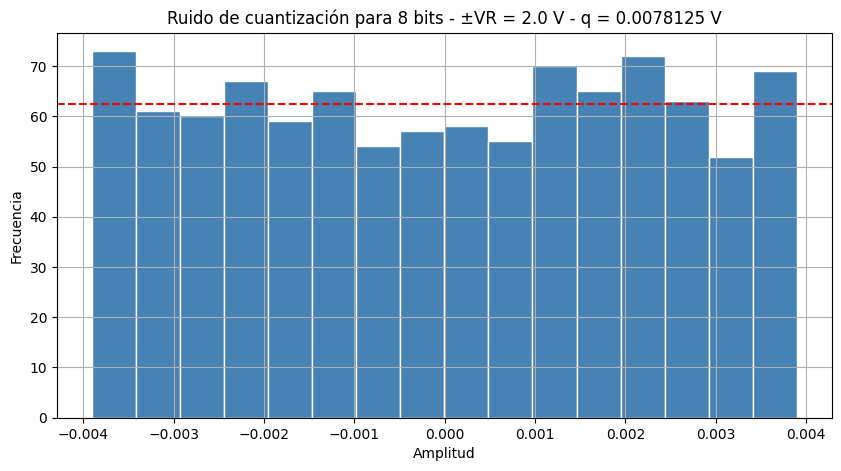

In [125]:
# Grafico 3: histograma del ruido de cuantizacion
ruido_cuantizacion = sQ - sR

plt.figure(figsize=(10, 5))
plt.hist(ruido_cuantizacion, bins = 16, color = 'steelblue', edgecolor = 'white')
plt.axhline(N / 16, color = 'red', linestyle = '--')   # linea uniforme esperada
plt.title('Ruido de cuantización para ' + str(B) + ' bits - ±VR = ' + str(Vf*2) + '.0 V - q = ' + str(q) + ' V')
plt.xlabel('Amplitud')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

## Bonus

B = 1 bits  ->  SNR = 10.79 dB
B = 2 bits  ->  SNR = 16.81 dB
B = 4 bits  ->  SNR = 28.85 dB
B = 8 bits  ->  SNR = 52.93 dB
B = 16 bits  ->  SNR = 101.09 dB
B = 24 bits  ->  SNR = 149.25 dB
B = 32 bits  ->  SNR = 197.41 dB


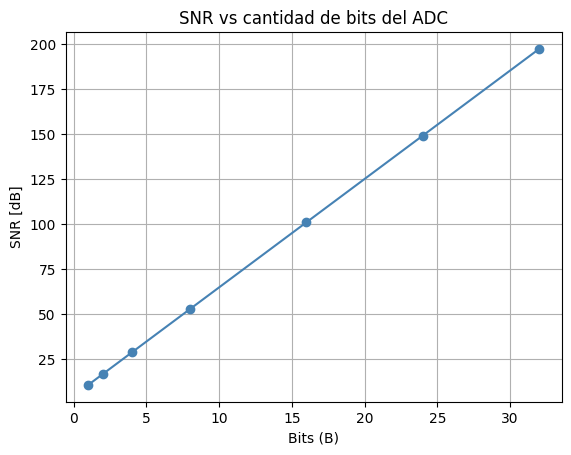

In [126]:
# Bonus 1 - SNR vs cantidad de bits
B_valores = [1, 2, 4, 8, 16, 24, 32]

sigma_x = amplitud / np.sqrt(2)   # desviacion estandar de la senoidal
Vfs = Vf

SNR_valores = []
for B in B_valores:
    SNR = 6.02 * B + 10.79 + 20 * np.log10(sigma_x / Vfs)
    SNR_valores.append(SNR)
    print("B =", B, "bits  ->  SNR =", round(SNR, 2), "dB")

plt.figure()
plt.plot(B_valores, SNR_valores, marker = 'o', color = 'steelblue')
plt.title('SNR vs cantidad de bits del ADC')
plt.xlabel('Bits (B)')
plt.ylabel('SNR [dB]')
plt.grid(True)
plt.show()

## Análisis y Conclusiones
### Gráfico en el tiempo 
en el ítem a) con 4 bits se puede observar  la diferencia entre la señal analógica y la señal cuantizada, ya que los escalones del ADC son grandes (q = 0.125 V). En el ítem b) con 8 bits, la señal de salida del ADC es prácticamente indistinguible de la señal analógica original, ya que el paso de cuantización se redujo a q = 0.0078 V, es decir, se volvió 16 veces más pequeño.
### Densidad de potencia
Al duplicar la cantidad de bits, el piso de ruido de cuantización desciende aproximadamente 6 dB por cada bit adicional. Pasar de 4 a 8 bits implica 4 bits más, lo que representa una reducción teórica de 24 dB en el piso digital. Esto se puede verificar comparando los valores de nQ entre ambos ítems. El piso analógico, en cambio, no varía porque kn = 1 en los dos casos.
### Histograma del ruido de cuantización 
En el ítem a) el histograma es aproximadamente uniforme en el intervalo [-q/2, q/2] = [-0.0625, 0.0625], lo que confirma que el error de cuantización se distribuye de forma uniforme, tal como predice la teoría. En el ítem b) el intervalo del histograma se reduce drásticamente, reflejando que el error de cuantización es mucho menor con más bits.
*Conclusión:* Aumentar la resolución del ADC de 4 a 8 bits mejora significativamente la calidad de la señal digitalizada, reduciendo el ruido de cuantización y acercando la salida digital a la señal analógica original. Esto se observa en los tres gráficos de forma consistente.
